44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

MODEL ACCURACIES
Logistic Regression: 0.7854
KNN: 0.7406
Decision Tree: 0.7299
Random Forest: 0.7854
ANN: 0.7868


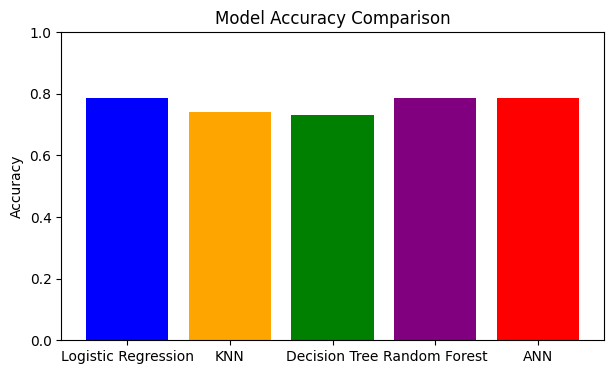

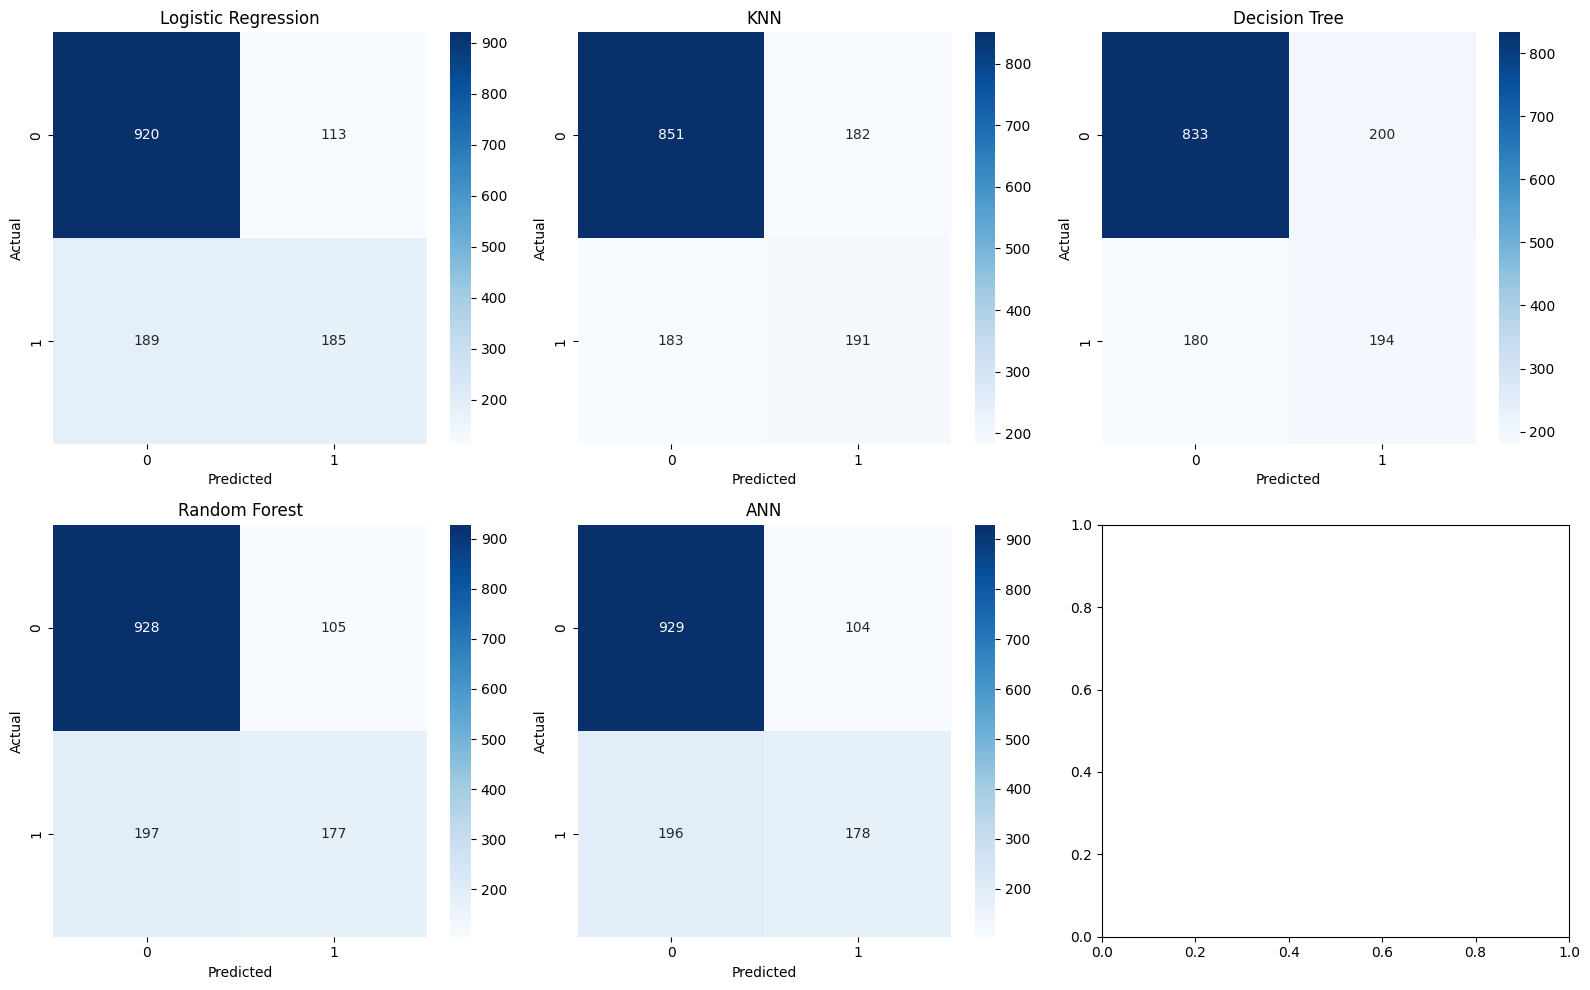

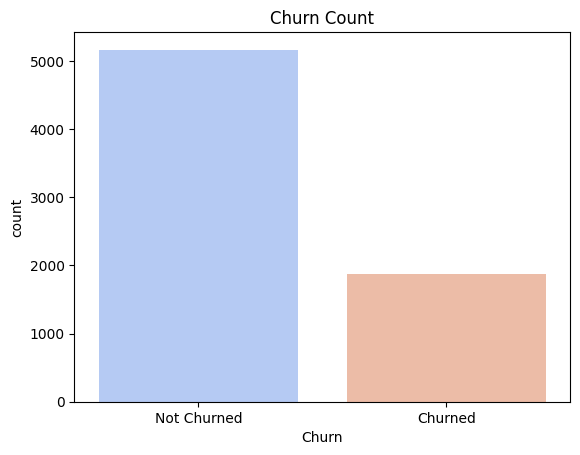

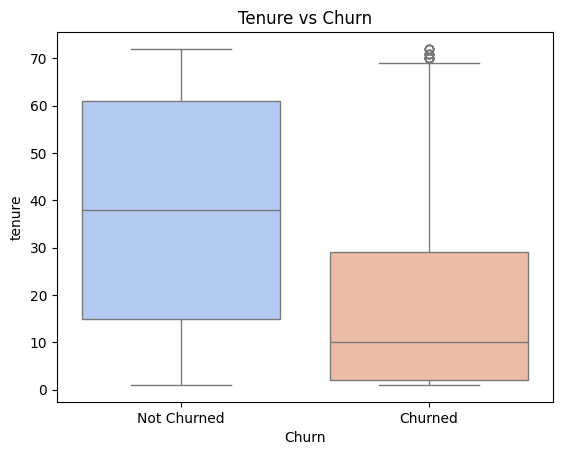

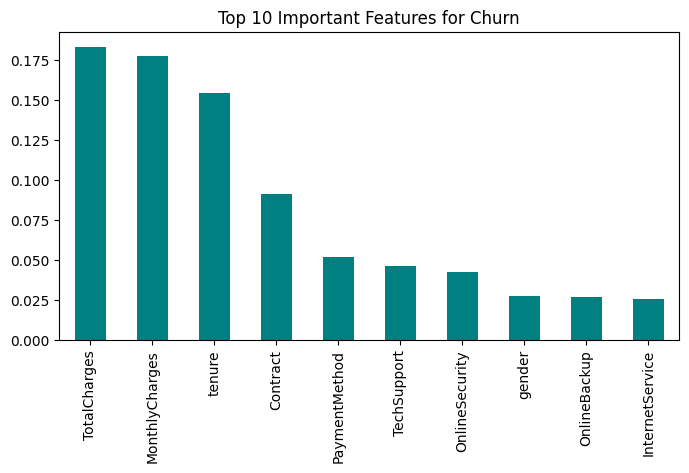

In [26]:
# =========================================
# TELCO CUSTOMER CHURN PREDICTION PROJECT
# =========================================

# ✅ Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
import warnings
warnings.filterwarnings("ignore")

# ✅ Load Dataset (Download from Kaggle: Telco Customer Churn)
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# ✅ Handle Missing Values & Drop Unwanted Columns
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
df.drop(columns=["customerID"], inplace=True)

# ✅ Encode Categorical Columns
encoder = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

# ✅ Split Data
X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Scale Data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ✅ Train ML Models
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = accuracy_score(y_test, preds)

# ✅ ANN Model
ann = Sequential()
ann.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
ann.add(Dense(8, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=35, verbose=0)
pred_ann = (ann.predict(X_test) > 0.5).astype(int).ravel()
results["ANN"] = accuracy_score(y_test, pred_ann)

# ✅ Accuracy Results
print("\nMODEL ACCURACIES")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

plt.figure(figsize=(7,4))
plt.bar(results.keys(), results.values(), color=["blue","orange","green","purple","red"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# ✅ Confusion Matrices (Corrected Block)
pred_lr  = models["Logistic Regression"].predict(X_test)
pred_knn = models["KNN"].predict(X_test)
pred_dt  = models["Decision Tree"].predict(X_test)
pred_rf  = models["Random Forest"].predict(X_test)

pred_dict = {
    "Logistic Regression": pred_lr,
    "KNN": pred_knn,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "ANN": pred_ann
}

fig, axes = plt.subplots(2,3, figsize=(16,10))
for ax, (name, preds) in zip(axes.flatten(), pred_dict.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


# ✅ Churn Distribution
sns.countplot(x=df["Churn"], palette="coolwarm")
plt.title("Churn Count")
plt.xticks([0,1],["Not Churned","Churned"])
plt.show()

# ✅ Tenure vs Churn
sns.boxplot(x=df["Churn"], y=df["tenure"], palette="coolwarm")
plt.title("Tenure vs Churn")
plt.xticks([0,1],["Not Churned","Churned"])
plt.show()

# ✅ Feature Importance (Random Forest)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
imp[:10].plot(kind='bar', figsize=(8,4), color='teal')
plt.title("Top 10 Important Features for Churn")
plt.show()
